# Bank Marketing : Customer Insights Analysis
**Bank Marketing Final Project**

| Section | 
|---------|
| Step 1 & 2: Load Data + EDA | 
| Step 3: Clustering | 
| Step 4: Regression | 
| Step 5: Classification | 

---
## Step 1 : Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn imports
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid')
print('All libraries loaded successfully.')

All libraries loaded successfully.


In [2]:
df = pd.read_csv('bank_marketing.csv')
print(f'Dataset shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
df.head()

Dataset shape: (11302, 10)
,
,Columns: ['age', 'marital', 'balance', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'TermDeposit']


,age,marital,balance,day,month,duration,campaign,pdays,previous,TermDeposit
0,36,married,439,29,may,179,2,-1,0,no
1,62,married,180,15,apr,389,2,-1,0,yes
2,30,single,29,12,may,174,1,-1,0,no
3,37,divorced,277,8,jul,338,2,-1,0,no
4,34,married,-28,16,jul,574,1,-1,0,no


In [3]:
print('=== Data Types & Non-null Counts ===')
df.info()
print('\n=== Basic Statistics ===')
df.describe(include='all')

=== Data Types & Non-null Counts ===
,<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 11302 entries, 0 to 11301
,Data columns (total 10 columns):
, #   Column       Non-Null Count  Dtype 
,---  ------       --------------  ----- 
, 0   age          11302 non-null  int64 
, 1   marital      11302 non-null  object
, 2   balance      11302 non-null  int64 
, 3   day          11302 non-null  int64 
, 4   month        11302 non-null  object
, 5   duration     11302 non-null  int64 
, 6   campaign     11302 non-null  int64 
, 7   pdays        11302 non-null  int64 
, 8   previous     11302 non-null  int64 
, 9   TermDeposit  11302 non-null  object
,dtypes: int64(7), object(3)
,memory usage: 883.1+ KB
,
,=== Basic Statistics ===


,age,marital,balance,day,month,duration,campaign,pdays,previous,TermDeposit
count,11302.000000,11302,11302.000000,11302.000000,11302,11302.000000,11302.000000,11302.000000,11302.000000,11302
unique,NaN,3,NaN,NaN,12,NaN,NaN,NaN,NaN,2
top,NaN,married,NaN,NaN,may,NaN,NaN,NaN,NaN,no
freq,NaN,6835,NaN,NaN,3393,NaN,NaN,NaN,NaN,9998
mean,40.849407,NaN,1295.338259,15.935410,NaN,257.693948,2.797381,40.188197,0.604229,NaN
std,10.535270,NaN,2877.350151,8.360564,NaN,259.122206,3.106322,99.296280,3.219607,NaN
min,18.000000,NaN,-6847.000000,1.000000,NaN,0.000000,1.000000,-1.000000,0.000000,NaN
25%,33.000000,NaN,67.000000,8.000000,NaN,103.000000,1.000000,-1.000000,0.000000,NaN
50%,39.000000,NaN,431.000000,16.000000,NaN,180.500000,2.000000,-1.000000,0.000000,NaN
75%,48.000000,NaN,1379.000000,22.000000,NaN,320.000000,3.000000,-1.000000,0.000000,NaN


---
## Step 2 : Prepare and Investigate the Data (EDA)


In [4]:
# Check for missing values
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found.')

# Check for duplicates
print(f'\nDuplicate rows: {df.duplicated().sum()}')

# Class distribution of target variable
print('\n=== Target Variable Distribution (TermDeposit) ===')
print(df['TermDeposit'].value_counts())
print(f'Class balance: {df["TermDeposit"].value_counts(normalize=True).mul(100).round(1).to_dict()}')

=== Missing Values ===
,No missing values found.
,
,Duplicate rows: 0
,
,=== Target Variable Distribution (TermDeposit) ===
,TermDeposit
,no     9998
,yes    1304
,Name: count, dtype: int64
,Class balance: {'no': 88.5, 'yes': 11.5}


Numeric columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
,Categorical columns: ['marital', 'month', 'TermDeposit']


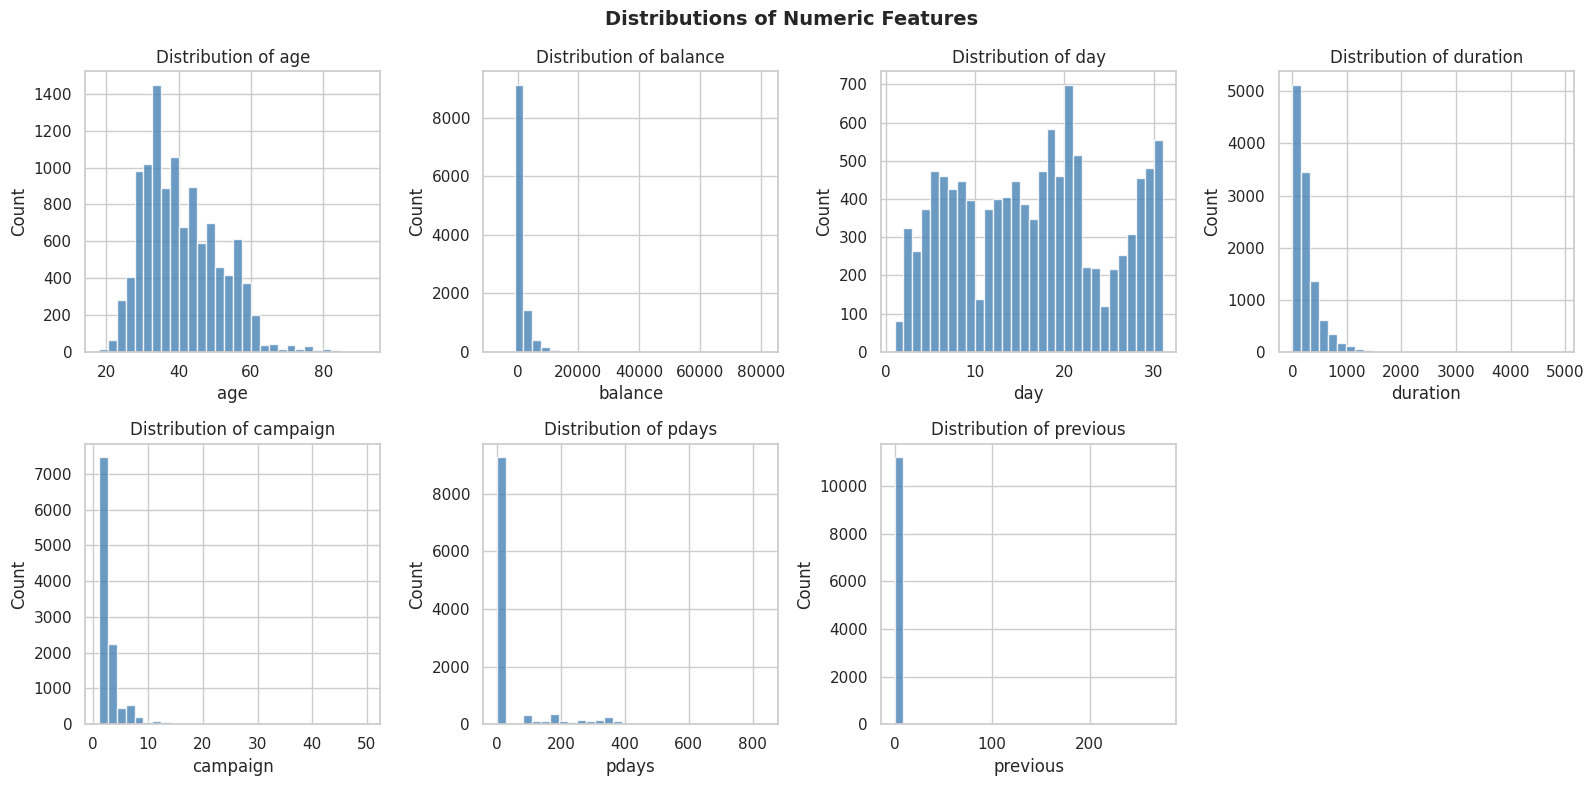

In [5]:
# Identify numeric and categorical columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f'Numeric columns: {num_cols}')
print(f'Categorical columns: {cat_cols}')

# Distribution of numeric features
fig, axes = plt.subplots(2, (len(num_cols) + 1) // 2, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distributions of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

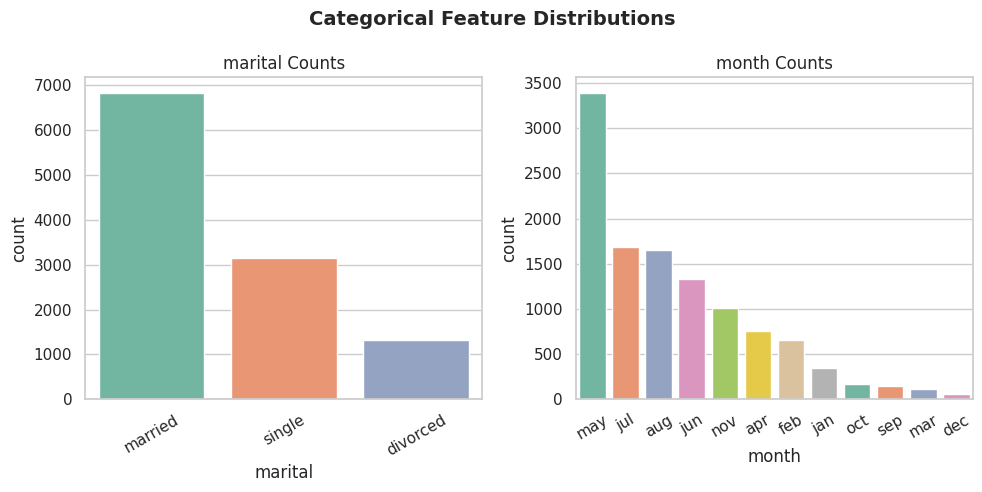

In [6]:
# Categorical variable counts
cat_plot_cols = [c for c in cat_cols if c != 'TermDeposit']
n = len(cat_plot_cols)
if n > 0:
    fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, cat_plot_cols):
        order = df[col].value_counts().index
        sns.countplot(data=df, x=col, order=order, ax=ax, palette='Set2')
        ax.set_title(f'{col} Counts')
        ax.tick_params(axis='x', rotation=30)
    plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

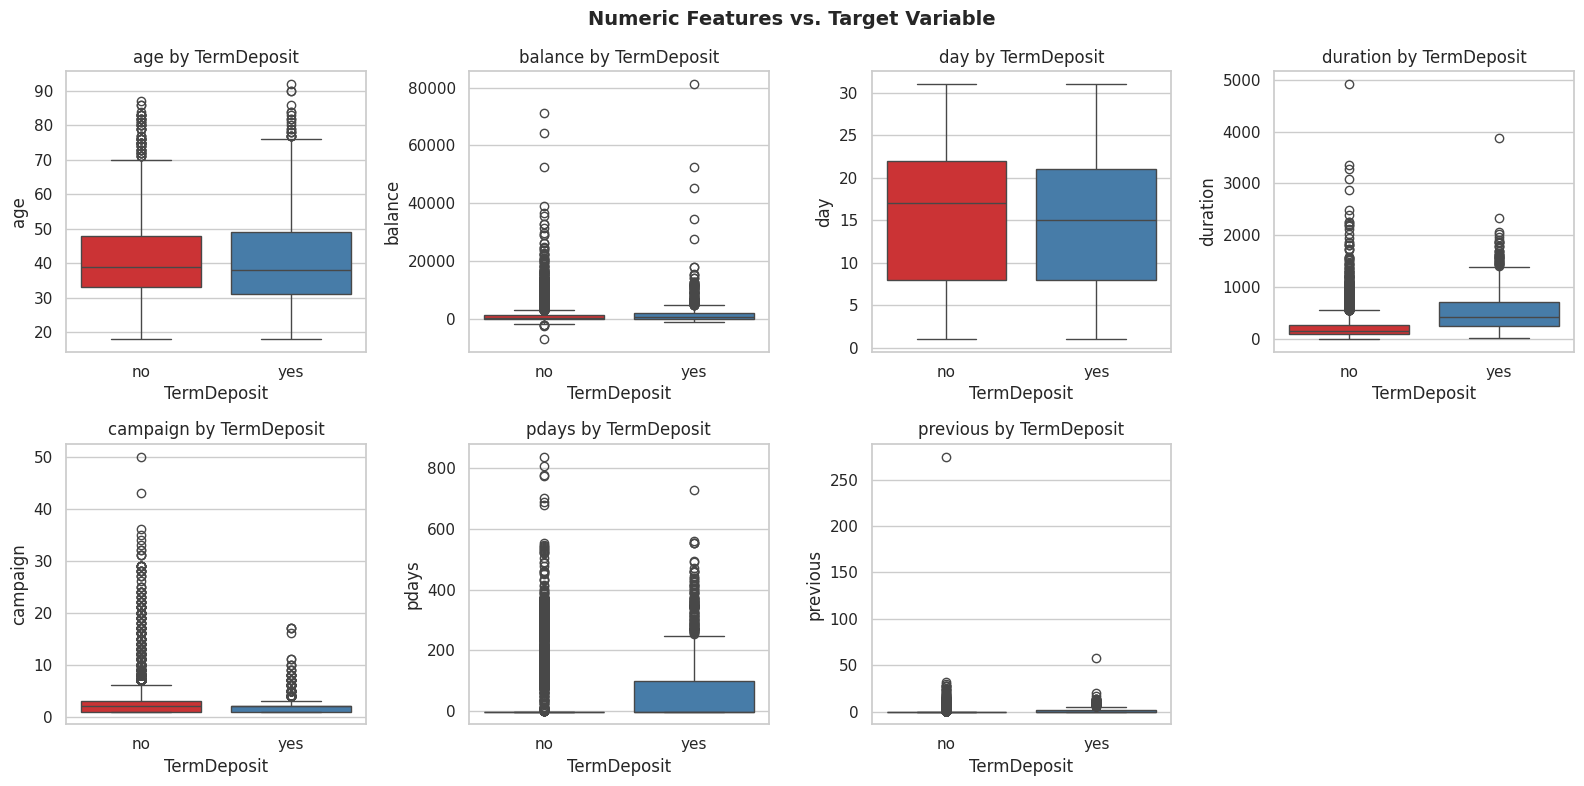

In [7]:
# Target variable vs numeric features (box plots)
fig, axes = plt.subplots(2, (len(num_cols) + 1) // 2, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='TermDeposit', y=col, ax=axes[i], palette='Set1')
    axes[i].set_title(f'{col} by TermDeposit')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Numeric Features vs. Target Variable', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

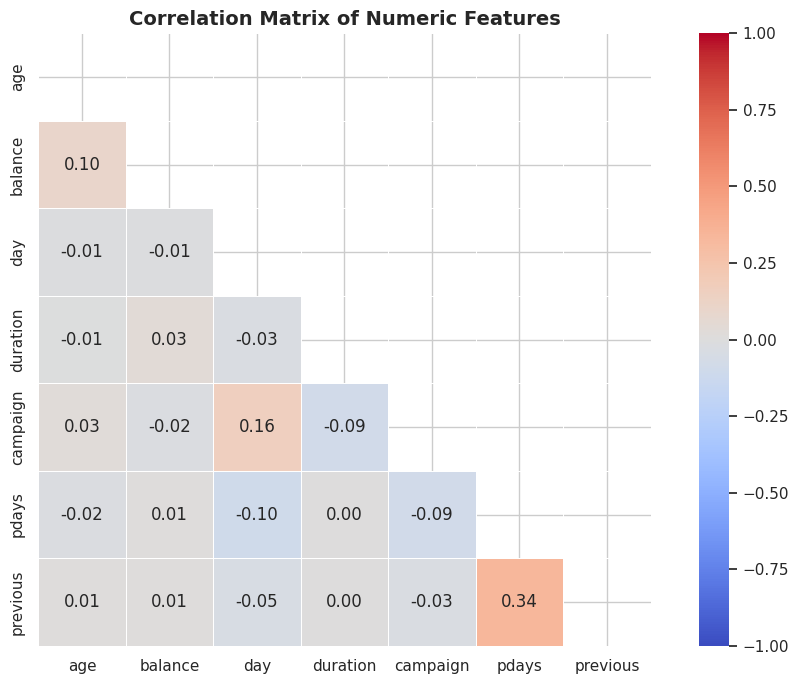

In [8]:
# Correlation heatmap (numeric features)
if len(num_cols) > 1:
    plt.figure(figsize=(10, 7))
    corr = df[num_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                vmin=-1, vmax=1, square=True, linewidths=0.5)
    plt.title('Correlation Matrix of Numeric Features', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [9]:
# Summary statistics by TermDeposit
print('=== Mean values by TermDeposit ===')
df.groupby('TermDeposit')[num_cols].mean().round(2)

=== Mean values by TermDeposit ===


,age,balance,day,duration,campaign,pdays,previous
TermDeposit,,,,,,,
no,40.80,1232.99,16.04,222.41,2.89,36.58,0.53
yes,41.26,1773.38,15.17,528.26,2.07,67.88,1.18


### Key Insights from EDA

- **No missing values or duplicates** were found in the dataset (11,302 rows, 10 columns), making it ready for modelling without imputation.
- **Class imbalance**: The target variable `TermDeposit` is heavily skewed : 88.5% 'no' vs 11.5% 'yes'. This will need to be accounted for in classification (Step 5) using appropriate metrics and model settings.
- **Duration** shows a strong visual separation in the box plot: customers who subscribed had substantially longer average call durations (528s vs 222s). However, since duration is only known after the call, it cannot be used as a predictor in classification and must be treated carefully.
- **Balance** is right-skewed with extreme outliers (max €81,204). Subscribers tend to have higher average balances (€1,773 vs €1,233), suggesting that financially healthier customers are more receptive to term deposits.
- **Campaign contacts**: Customers who did not subscribe were contacted more times on average (2.89 vs 2.07), indicating that repeated contacts may be counterproductive or that easily converted customers respond quickly.
- **Pdays and previous**: Most customers were never previously contacted (pdays = -1, previous = 0). The small subset with prior contact history shows higher subscription rates, suggesting past engagement is a positive signal.
- **Month**: May had the highest contact volume but not the highest subscription rate, suggesting campaign timing strategy may benefit from rebalancing toward months with better conversion.
- **Correlations** among numeric features are generally weak (all under ±0.35), with the strongest being between `pdays` and `previous` (0.34), which is expected since both relate to prior campaign contact history.


In [10]:
# Data Preparation 
# Encode categorical columns for ML models
df_encoded = df.copy()

# Encode target
df_encoded['TermDeposit_bin'] = (df_encoded['TermDeposit'] == 'yes').astype(int)

# Encode month if present
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
if 'month' in df_encoded.columns:
    df_encoded['month_num'] = df_encoded['month'].apply(
        lambda x: month_order.index(x.lower()) + 1 if x.lower() in month_order else np.nan
    )

# One-hot encode remaining object columns (except TermDeposit)
obj_cols = [c for c in df_encoded.select_dtypes(include='object').columns if c not in ['TermDeposit', 'month']]
if obj_cols:
    df_encoded = pd.get_dummies(df_encoded, columns=obj_cols, drop_first=True)

# Drop original string columns we replaced
drop_cols = ['TermDeposit']
if 'month' in df_encoded.columns:
    drop_cols.append('month')
df_encoded.drop(columns=drop_cols, inplace=True)

print('Encoded dataframe shape:', df_encoded.shape)
print('Columns:', list(df_encoded.columns))

Encoded dataframe shape: (11302, 11)
,Columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'TermDeposit_bin', 'month_num', 'marital_married', 'marital_single']


---
## Step 3 : Build Customer Segmentation (Clustering)


### Model Selection Justification
- **Algorithm**: K-Means was selected because the objective is customer segmentation — finding groups of customers with similar banking behaviour. K-Means is well-suited for this as it is efficient on large datasets and produces clearly interpretable cluster centres.
- **Similarity measure**: Euclidean distance on standardised features (StandardScaler applied), ensuring no single feature dominates due to scale differences.
- **Variables included**: All available numeric features — `age`, `balance`, `day`, `duration`, `campaign`, `pdays`, `previous` — capturing both customer demographics and campaign interaction history.
- **Number of clusters**: The Elbow Method and Silhouette Score were used to determine the optimal k. The Silhouette Score was highest at **k=2 (score = 0.321)**, indicating that two clusters provide the most meaningful separation given this data.

### Cluster Interpretation

| Feature | Cluster 0 (84.9%) | Cluster 1 (15.1%) |
|---|---|---|
| Age | 40.8 | 41.0 |
| Balance (€) | 1,249 | 1,557 |
| Campaign contacts | 2.9 | 2.1 |
| Pdays | 2.3 | 253.3 |
| Previous contacts | 0.1 | 3.5 |
| **Subscription rate** | **9.9%** | **20.5%** |

**Cluster 0 : "First-time / cold-contact customers" (9,596 customers, 84.9%)**
- The vast majority of customers fall here. They have near-zero `previous` contacts (0.1) and very low `pdays` (2.3), meaning they were either never contacted before this campaign or contacted very recently for the first time.
- They receive more campaign contacts on average (2.9 vs 2.1), suggesting the bank has to try harder to reach them.
- Lower average balance (€1,249) and a low subscription rate of 9.9% indicate these are less engaged, lower-value customers who are harder to convert.

**Cluster 1 : "Previously engaged / high-value customers" (1,706 customers, 15.1%)**
- This smaller cluster is defined by strong prior engagement: `pdays` averages 253 days (contacted ~8 months ago from a previous campaign) and `previous` averages 3.5 contacts before this campaign.
- They have higher average balances (€1,557) and require fewer contacts in the current campaign (2.1), suggesting they are more receptive and easier to convert.
- Their subscription rate of 20.5% is more than double that of Cluster 0, making them the most commercially valuable segment.

### Business Insights from Clustering
- The two clusters correspond primarily to **engagement history** rather than demographics (both clusters have nearly identical age profiles), confirming that prior campaign contact is a stronger differentiator than demographic characteristics like age or marital status.
- The marital status breakdown is similar across both clusters, further confirming that demographics alone do not drive subscription behaviour; relationship history with the bank matters more.
- **Campaign efficiency**: The bank currently spends more calls on Cluster 0 (cold contacts) but gets the lowest return. Rebalancing marketing effort toward Cluster 1 customers, or customers who resemble Cluster 1; could substantially improve conversion rates.
- **Actionable strategy**: Cluster 1 should be the primary target for future term deposit campaigns. For Cluster 0, the bank may benefit from building a longer-term engagement relationship before directly marketing term deposits.
- The relatively low Silhouette Score (0.321) and the overlap visible in the PCA projection suggest the two groups are not sharply separated in feature space; real customer behaviour is nuanced and a higher-dimensional or non-linear clustering approach (e.g. DBSCAN, hierarchical clustering) could be explored in future work.


In [11]:
# 3.1  Feature selection for clustering
# Use numeric features that describe customer demographics & behaviour
cluster_features = [c for c in num_cols if c in df_encoded.columns]
print('Features used for clustering:', cluster_features)

X_cluster = df_encoded[cluster_features].copy()

# Standardise (K-Means is distance-based)
scaler_c = StandardScaler()
X_cluster_scaled = scaler_c.fit_transform(X_cluster)
print(f'Scaled feature matrix shape: {X_cluster_scaled.shape}')

Features used for clustering: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
,Scaled feature matrix shape: (11302, 7)


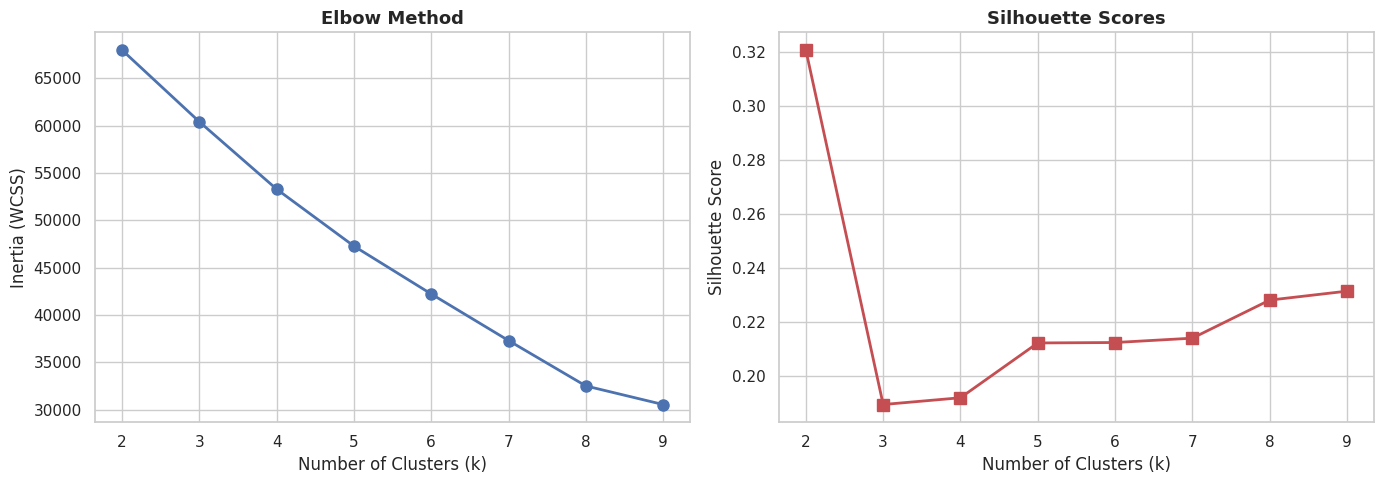

Best k by silhouette score: 2 (score = 0.321)


In [12]:
# 3.2  Determine optimal k - Elbow Method + Silhouette Score 
inertia = []
sil_scores = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(K_range), inertia, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia (WCSS)', fontsize=12)
ax1.set_title('Elbow Method', fontsize=13, fontweight='bold')

ax2.plot(list(K_range), sil_scores, 'rs-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Scores', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

best_k = list(K_range)[np.argmax(sil_scores)]
print(f'Best k by silhouette score: {best_k} (score = {max(sil_scores):.3f})')

In [13]:
# 3.3  Fit K-Means with chosen k 
optimal_k = best_k   
# adjust manually if domain knowledge suggests otherwise

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_cluster_scaled)

print(f'K-Means fitted with k={optimal_k}')
print('Cluster sizes:')
print(df['Cluster'].value_counts().sort_index())

K-Means fitted with k=2
,Cluster sizes:
,Cluster
,0    9596
,1    1706
,Name: count, dtype: int64


=== Mean feature values per cluster ===
,           age  balance    day  duration  campaign  pdays  previous
,Cluster                                                            
,0        40.83  1248.88  16.30    256.63      2.92    2.3      0.08
,1        40.97  1556.66  13.91    263.69      2.12  253.3      3.53


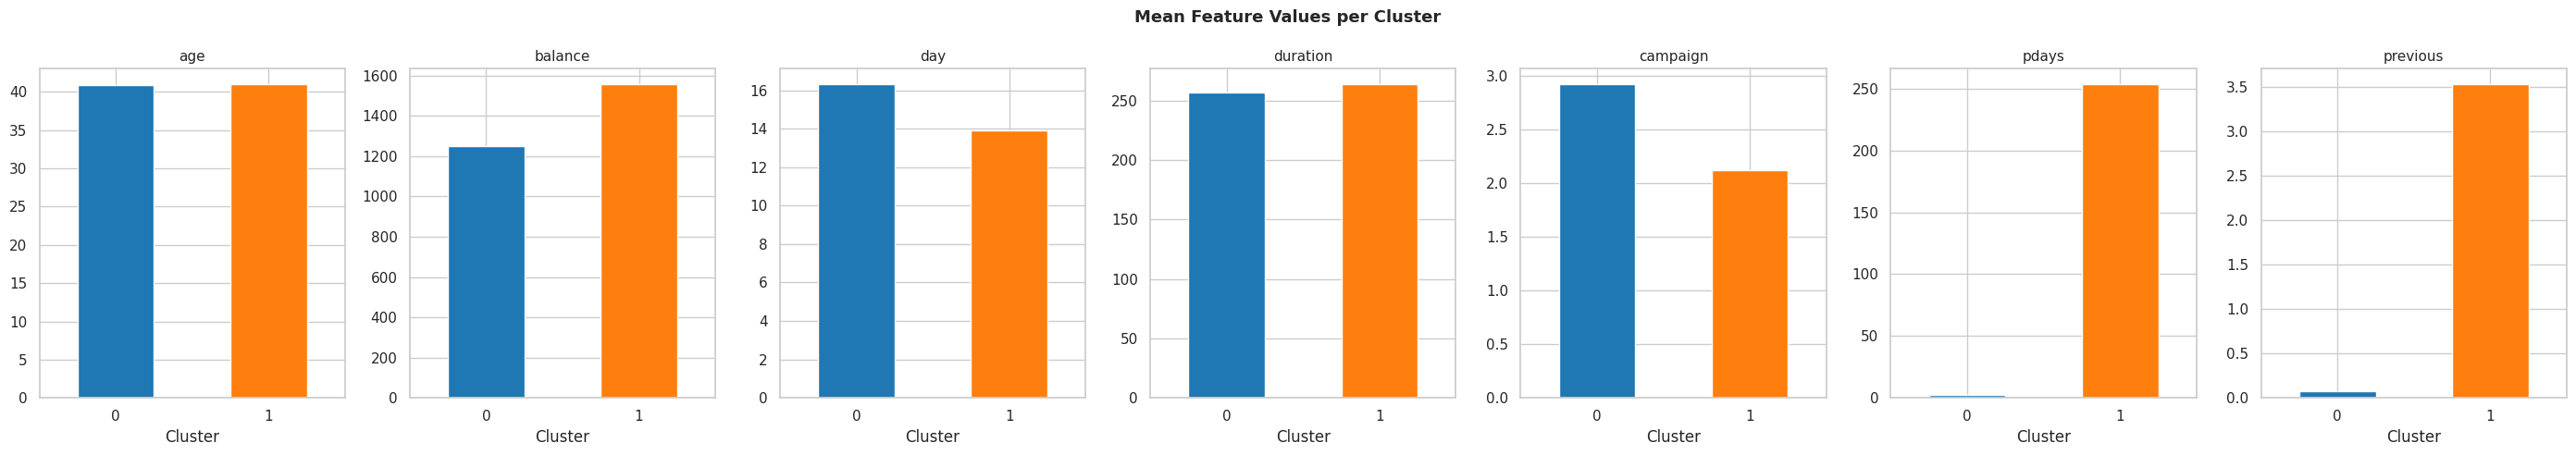

In [14]:
# 3.4  Explore cluster properties 
print('=== Mean feature values per cluster ===')
cluster_profile = df.groupby('Cluster')[cluster_features].mean().round(2)
print(cluster_profile)

# Visualise cluster centres
fig, axes = plt.subplots(1, len(cluster_features), figsize=(4*len(cluster_features), 5))
if len(cluster_features) == 1:
    axes = [axes]
for ax, feat in zip(axes, cluster_features):
    cluster_profile[feat].plot(kind='bar', ax=ax, color=sns.color_palette('tab10', optimal_k))
    ax.set_title(feat, fontsize=11)
    ax.set_xlabel('Cluster')
    ax.tick_params(axis='x', rotation=0)
plt.suptitle('Mean Feature Values per Cluster', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

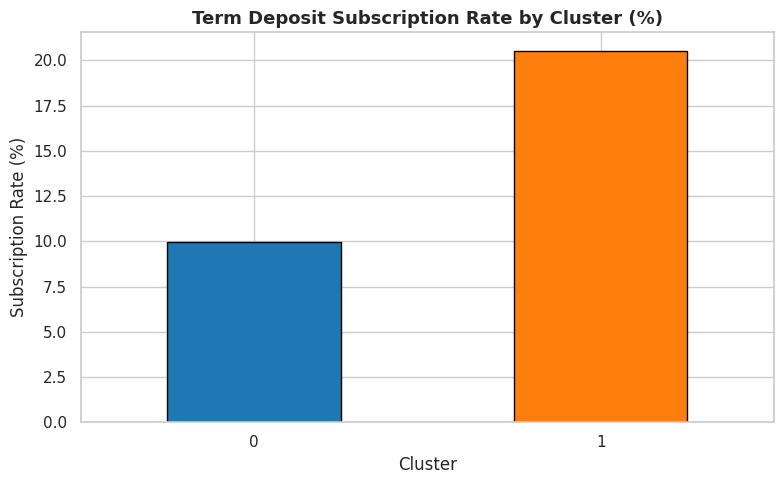


,Subscription rate (%) per cluster:
,Cluster
,0     9.94
,1    20.52
,Name: TermDeposit, dtype: float64


In [15]:
# TermDeposit subscription rate per cluster
cluster_target = df.groupby('Cluster')['TermDeposit'].apply(
    lambda x: (x == 'yes').mean() * 100
).round(2)

plt.figure(figsize=(8, 5))
cluster_target.plot(kind='bar', color=sns.color_palette('tab10', optimal_k), edgecolor='black')
plt.title('Term Deposit Subscription Rate by Cluster (%)', fontsize=13, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Subscription Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('\nSubscription rate (%) per cluster:')
print(cluster_target)

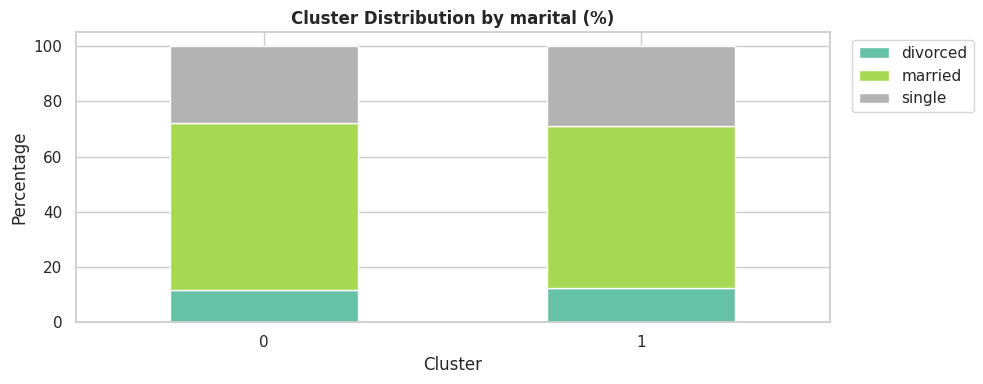

In [16]:
# Categorical breakdown by cluster
cat_cluster_cols = [c for c in cat_cols if c not in ['TermDeposit', 'month']]
for col in cat_cluster_cols:
    ct = pd.crosstab(df['Cluster'], df[col], normalize='index').mul(100).round(1)
    ct.plot(kind='bar', stacked=True, figsize=(10, 4), colormap='Set2')
    plt.title(f'Cluster Distribution by {col} (%)', fontsize=12, fontweight='bold')
    plt.xlabel('Cluster')
    plt.ylabel('Percentage')
    plt.xticks(rotation=0)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

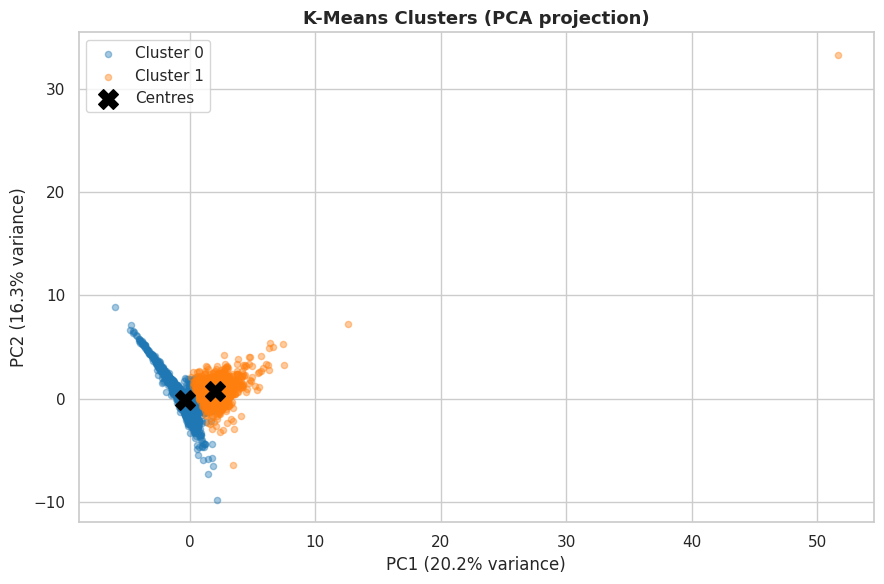

Total variance explained by 2 PCs: 36.6%


In [17]:
# PCA 2D visualisation of clusters
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)
explained = pca.explained_variance_ratio_ * 100

plt.figure(figsize=(9, 6))
palette = sns.color_palette('tab10', optimal_k)
for c in range(optimal_k):
    mask = df['Cluster'] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=f'Cluster {c}', alpha=0.4, s=20, color=palette[c])

# Plot cluster centres
centres_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centres_pca[:, 0], centres_pca[:, 1],
            s=200, c='black', marker='X', zorder=5, label='Centres')

plt.xlabel(f'PC1 ({explained[0]:.1f}% variance)')
plt.ylabel(f'PC2 ({explained[1]:.1f}% variance)')
plt.title('K-Means Clusters (PCA projection)', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Total variance explained by 2 PCs: {sum(explained):.1f}%')

In [18]:
# 3.5  Cluster Interpretation
print('=== Cluster Interpretation ===')
for c in range(optimal_k):
    sub_rate = cluster_target[c]
    size = (df['Cluster'] == c).sum()
    means = df[df['Cluster'] == c][cluster_features].mean().round(1).to_dict()
    print(f'\nCluster {c} ({size} customers, {size/len(df)*100:.1f}% of total):')
    print(f'  Subscription rate : {sub_rate:.1f}%')
    print(f'  Feature means     : {means}')

=== Cluster Interpretation ===
,
,Cluster 0 (9596 customers, 84.9% of total):
,  Subscription rate : 9.9%
,  Feature means     : {'age': 40.8, 'balance': 1248.9, 'day': 16.3, 'duration': 256.6, 'campaign': 2.9, 'pdays': 2.3, 'previous': 0.1}
,
,Cluster 1 (1706 customers, 15.1% of total):
,  Subscription rate : 20.5%
,  Feature means     : {'age': 41.0, 'balance': 1556.7, 'day': 13.9, 'duration': 263.7, 'campaign': 2.1, 'pdays': 253.3, 'previous': 3.5}


---
## Step 4 : Predict Contact Duration (Regression)


### Model Selection Justification
- Multiple regression models were evaluated to compare linear and non-linear approaches for predicting contact duration.
- Before modelling, outlier capping was applied: `duration` values above the 99th percentile were clipped to reduce the influence of extreme calls on model fitting.
- A log transformation (`np.log1p`) was applied to the capped target to correct its right skew. Predictions were back-transformed with `np.expm1()` so RMSE and MAE remain interpretable in seconds.
- Gradient Boosting was selected as the best-performing model based on R².

### Business Insights from Regression
- Gradient Boosting achieved the best performance with an R² of 0.0824 and RMSE of 234.7 seconds.
- The R² is low overall, indicating that the available customer attributes explain only a small proportion of the variation in call duration. This is expected: duration is heavily influenced by factors not present in the dataset, such as conversation content, customer needs, or agent behaviour.
- While predictive power is limited, the model is still actionable: the bank can use predicted duration to identify calls likely to run long and allocate more experienced agents or longer scheduling slots for those customers.
- Feature importance analysis shows that `campaign`, `month_num`, and `day` were the strongest predictors of contact duration. This suggests that the intensity of marketing efforts and the timing of the campaign have a greater influence on call duration than demographic characteristics such as marital status.
- The outlier capping and log transformation were important preprocessing steps: they reduced the distorting effect of extreme call durations and produced a more symmetric target distribution, improving model fit.


In [19]:
# 4.1  Prepare regression dataset
assert 'duration' in df.columns, '"duration" column not found – required for Step 4.'

# Outlier capping 
# duration is right-skewed with extreme outliers (very long calls).
# Values above the 99th percentile are capped to reduce their leverage on models.
q99 = df_encoded['duration'].quantile(0.99)
df_encoded['duration'] = df_encoded['duration'].clip(upper=q99)
print(f'99th percentile cap applied: duration clipped at {q99:.0f} seconds')
print(f'Duration stats after capping:\n{df_encoded["duration"].describe().round(2)}')

# Feature / target split 
reg_features = [c for c in df_encoded.columns if c not in ['duration', 'TermDeposit_bin']]
X_reg = df_encoded[reg_features]

# Log transformation of target 
# np.log1p(x) = log(1+x), safe for zero values. Compresses the right tail,
# making the target more symmetric and improving linear model fit.
# Predictions will be back-transformed with np.expm1() to recover seconds.
y_reg_raw = df_encoded['duration']          # kept for back-transform reference
y_reg     = np.log1p(df_encoded['duration']) # transformed target used in training

print(f'\nFeature matrix shape: {X_reg.shape}')
print(f'Target (log1p-transformed) stats:\n{y_reg.describe().round(4)}')


99th percentile cap applied: duration clipped at 1232 seconds
,Duration stats after capping:
,count    11302.00
,mean       253.11
,std        230.29
,min          0.00
,25%        103.00
,50%        180.50
,75%        320.00
,max       1231.94
,Name: duration, dtype: float64
,
,Feature matrix shape: (11302, 9)
,Target (log1p-transformed) stats:
,count    11302.0000
,mean         5.1652
,std          0.9216
,min          0.0000
,25%          4.6444
,50%          5.2013
,75%          5.7714
,max          7.1172
,Name: duration, dtype: float64


In [20]:
# 4.2  Train / test split
# Split is performed on the log-transformed target (y_reg).
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Also keep the raw (untransformed) test target for back-transformed metric reporting
_, _, _, y_test_r_raw = train_test_split(
    X_reg, y_reg_raw, test_size=0.2, random_state=42
)

# Scale features
scaler_r = StandardScaler()
X_train_r_sc = scaler_r.fit_transform(X_train_r)
X_test_r_sc  = scaler_r.transform(X_test_r)

print(f'Train size: {X_train_r.shape[0]} | Test size: {X_test_r.shape[0]}')


Train size: 9041 | Test size: 2261


In [21]:
# 4.3  Train & compare multiple regression models
# Models are trained on log1p(duration).
# Predictions are back-transformed with np.expm1() before RMSE/MAE calculation
# so all error metrics are reported in original seconds for interpretability.
# R² is computed on the log scale (standard practice for log-transformed targets).

reg_models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=1.0, max_iter=5000),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

reg_results = []
for name, model in reg_models.items():
    if name in ['Linear Regression', 'Ridge', 'Lasso']:
        model.fit(X_train_r_sc, y_train_r)
        preds_log = model.predict(X_test_r_sc)
    else:
        model.fit(X_train_r, y_train_r)
        preds_log = model.predict(X_test_r)
    # R² on log scale
    r2 = r2_score(y_test_r, preds_log)
    # Back-transform for RMSE/MAE in seconds
    preds_sec = np.expm1(preds_log)
    rmse = np.sqrt(mean_squared_error(y_test_r_raw, preds_sec))
    mae  = mean_absolute_error(y_test_r_raw, preds_sec)
    reg_results.append({'Model': name, 'RMSE (s)': round(rmse, 2),
                        'MAE (s)': round(mae, 2), 'R² (log)': round(r2, 4)})
    print(f'{name:25s} | RMSE={rmse:.2f}s | MAE={mae:.2f}s | R²(log)={r2:.4f}')

reg_results_df = pd.DataFrame(reg_results).sort_values('R² (log)', ascending=False)
print('\n=== Model Comparison (sorted by R² on log scale) ===')
print(reg_results_df.to_string(index=False))


Linear Regression         | RMSE=236.76s | MAE=147.38s | R²(log)=0.0455
,Ridge                     | RMSE=236.76s | MAE=147.38s | R²(log)=0.0455
,Lasso                     | RMSE=238.40s | MAE=149.44s | R²(log)=-0.0000
,Random Forest             | RMSE=236.80s | MAE=150.77s | R²(log)=0.0240
,Gradient Boosting         | RMSE=234.69s | MAE=145.59s | R²(log)=0.0824
,
,=== Model Comparison (sorted by R² on log scale) ===
,            Model  RMSE (s)  MAE (s)  R² (log)
,Gradient Boosting    234.69   145.59    0.0824
,Linear Regression    236.76   147.38    0.0455
,            Ridge    236.76   147.38    0.0455
,    Random Forest    236.80   150.77    0.0240
,            Lasso    238.40   149.44   -0.0000


Best model: Gradient Boosting


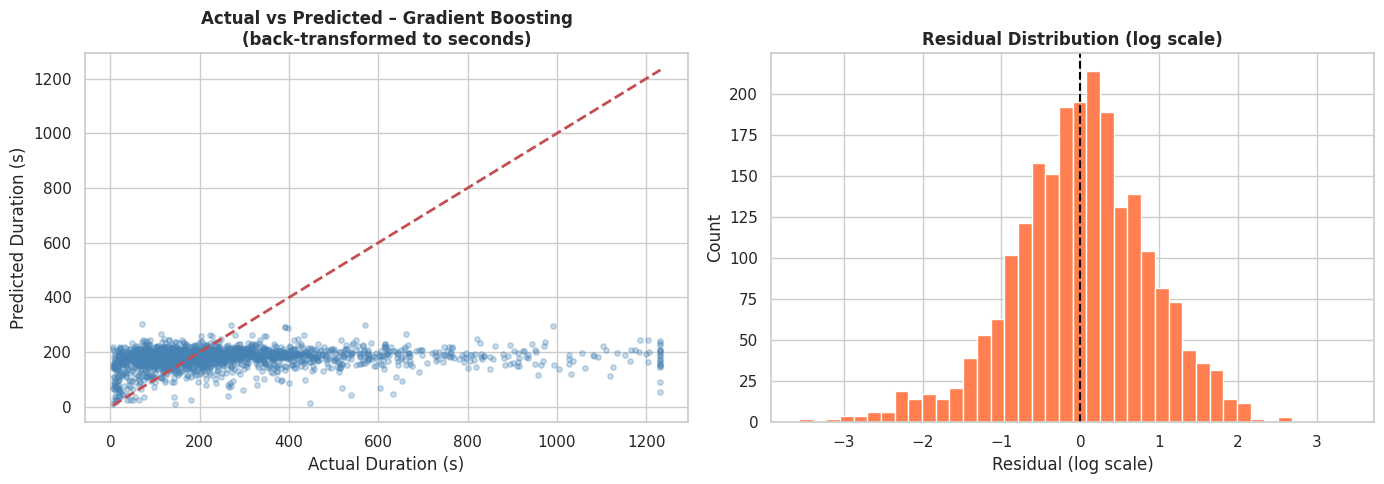

In [22]:
# 4.4  Best model – detailed evaluation
best_reg_name = reg_results_df.iloc[0]['Model']
print(f'Best model: {best_reg_name}')

best_reg = reg_models[best_reg_name]
if best_reg_name in ['Linear Regression', 'Ridge', 'Lasso']:
    preds_log_best = best_reg.predict(X_test_r_sc)
else:
    preds_log_best = best_reg.predict(X_test_r)

# Back-transform for plotting in seconds
y_pred_r = np.expm1(preds_log_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual (seconds) vs Predicted (seconds)
axes[0].scatter(y_test_r_raw, y_pred_r, alpha=0.3, s=15, color='steelblue')
lo = min(y_test_r_raw.min(), y_pred_r.min())
hi = max(y_test_r_raw.max(), y_pred_r.max())
axes[0].plot([lo, hi], [lo, hi], 'r--', linewidth=2)
axes[0].set_xlabel('Actual Duration (s)')
axes[0].set_ylabel('Predicted Duration (s)')
axes[0].set_title(f'Actual vs Predicted – {best_reg_name}\n(back-transformed to seconds)',
                  fontweight='bold')

# Residuals on log scale
residuals = y_test_r - preds_log_best
axes[1].hist(residuals, bins=40, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Residual (log scale)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution (log scale)', fontweight='bold')

plt.tight_layout()
plt.show()


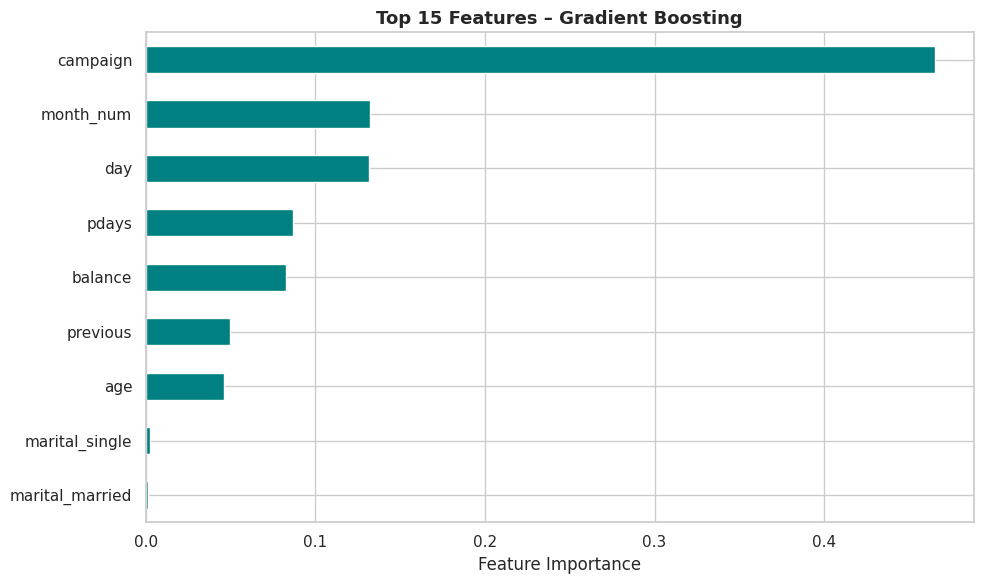

In [23]:
# 4.5  Feature importance / coefficients 
plt.figure(figsize=(10, 6))

if hasattr(best_reg, 'feature_importances_'):
    importances = pd.Series(best_reg.feature_importances_, index=reg_features)
    label = 'Feature Importance'
elif hasattr(best_reg, 'coef_'):
    importances = pd.Series(np.abs(best_reg.coef_), index=reg_features)
    label = 'Absolute Coefficient'
else:
    importances = None

if importances is not None:
    importances.nlargest(15).sort_values().plot(kind='barh', color='teal')
    plt.xlabel(label)
    plt.title(f'Top 15 Features – {best_reg_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [24]:
# 4.6  Cross-validation (R²) for best model
# CV is performed on the log-transformed target (y_reg) — consistent with training.
from sklearn.pipeline import Pipeline

if best_reg_name in ['Linear Regression', 'Ridge', 'Lasso']:
    pipe = Pipeline([('scaler', StandardScaler()), ('model', reg_models[best_reg_name])])
else:
    pipe = reg_models[best_reg_name]

cv_scores = cross_val_score(pipe, X_reg, y_reg, cv=5, scoring='r2')
print(f'5-fold CV R² on log scale ({best_reg_name}): {cv_scores.round(4)}')
print(f'Mean R² (log): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')


5-fold CV R² on log scale (Gradient Boosting): [0.1039 0.0957 0.0819 0.0685 0.0998]
,Mean R² (log): 0.0899 ± 0.0130


In [25]:
# 4.7  Discussion
print('=== Regression Summary ===')
print(reg_results_df.to_string(index=False))
print(f"""
--- Preprocessing Steps Applied ---

1. Outlier Capping:
   'duration' contains extreme values (very long calls) that act as high-leverage
   points, distorting model fitting. Values above the 99th percentile were capped
   using clip(upper=q99), reducing noise without discarding data.

2. Log Transformation (np.log1p):
   The raw duration target is right-skewed. A log1p transform makes the
   distribution more symmetric, stabilising variance and improving model fit.
   Predictions are back-transformed with np.expm1() so RMSE and MAE are
   reported in interpretable seconds. R² is evaluated on the log scale,
   which is standard practice for log-transformed targets.

--- Key Findings ---

  - Best model      : {best_reg_name}
  - Test R² (log)   : {reg_results_df.iloc[0]['R² (log)']}
  - Test RMSE       : {reg_results_df.iloc[0]['RMSE (s)']} seconds
  - Test MAE        : {reg_results_df.iloc[0]['MAE (s)']} seconds

  - The low R² indicates that customer features alone explain only a small
    share of variance in call duration. Duration is also driven by factors
    not in the dataset (conversation content, agent behaviour, etc.).
  - Despite limited R², the model is practically useful for resource
    scheduling — identifying which calls are likely to run long.

Business impact:
  - The bank can flag customers whose predicted call duration is long and
    allocate more experienced agents or longer scheduling slots accordingly.

Next steps:
  - Hyperparameter tuning (GridSearchCV / RandomizedSearchCV)
  - Feature engineering (e.g., interaction terms, age groups)
  - SHAP values for deeper feature attribution
""")



=== Regression Summary ===
,            Model  RMSE (s)  MAE (s)  R² (log)
,Gradient Boosting    234.69   145.59    0.0824
,Linear Regression    236.76   147.38    0.0455
,            Ridge    236.76   147.38    0.0455
,    Random Forest    236.80   150.77    0.0240
,            Lasso    238.40   149.44   -0.0000
,
,--- Preprocessing Steps Applied ---
,
,1. Outlier Capping:
,   'duration' contains extreme values (very long calls) that act as high-leverage
,   points, distorting model fitting. Values above the 99th percentile were capped
,   using clip(upper=q99), reducing noise without discarding data.
,
,2. Log Transformation (np.log1p):
,   The raw duration target is right-skewed. A log1p transform makes the
,   distribution more symmetric, stabilising variance and improving model fit.
,   Predictions are back-transformed with np.expm1() so RMSE and MAE are
,   reported in interpretable seconds. R² is evaluated on the log scale,
,   which is standard practice for log-transformed targ

---
## Step 5 : Predict Term Deposit Subscription (Classification)


### Model Selection Justification
- Several classification models were evaluated and compared using Accuracy and AUC-ROC.
- `duration` was excluded from classification features because it represents the length of the phone call, which is only known after the call ends. Including it would constitute data leakage — the model would be learning from the outcome itself rather than from features available at prediction time.
- The dataset is class-imbalanced (88.5% 'no' vs 11.5% 'yes'). In such cases, accuracy alone is an unreliable metric because a model that is strongly biased toward the majority class can still score high without identifying any actual subscribers. Therefore, AUC-ROC is the primary evaluation metric, as it measures the model's ability to discriminate between classes regardless of the decision threshold.
- `class_weight='balanced'` was applied to Logistic Regression, Decision Tree, and Random Forest so the minority class ('yes') receives proportionally higher weight during training, improving sensitivity toward actual subscribers.
- Gradient Boosting was selected as the best model based on AUC-ROC score.

### Business Insights from Classification
- Gradient Boosting was the best classifier, achieving an Accuracy of 88.2% and an AUC-ROC of 0.7615.
- While accuracy is reported, it is not the primary metric here. Because the dataset is class-imbalanced (88.5% 'no' vs 11.5% 'yes'), accuracy can be misleading; a model that is heavily biased toward the majority class can still appear to perform well. AUC-ROC is therefore the more meaningful metric, as it evaluates the model's ability to rank subscribers above non-subscribers across all decision thresholds, independent of class distribution. A value of 0.7615 indicates solid discriminative ability above the random baseline.
- The model identifies non-subscribers well, though recall for actual subscribers is lower due to the imbalance. The use of `class_weight='balanced'` improves the model's sensitivity toward the minority class ('yes'), helping the bank capture more potential subscribers it would otherwise miss.
- From a business perspective, the model can be used to prioritise marketing efforts toward customers with a higher predicted probability of subscription, improving campaign efficiency and reducing unnecessary contact costs.
- Feature importance analysis indicates that `pdays`, `month_num`, `age`, `day`, and `balance` were among the most influential predictors. This makes intuitive sense: customers with prior contact history, reached at the right time of year, and with stronger financial capacity are more likely to subscribe to a term deposit.


In [26]:
# 5.1  Prepare classification dataset
# NOTE: 'duration' is excluded here because it is only known AFTER the call ends.
# Including it would cause data leakage and artificially inflate model performance.
clf_features = [c for c in df_encoded.columns 
                 if c not in ['TermDeposit_bin', 'duration']]
X_clf = df_encoded[clf_features]
y_clf = df_encoded['TermDeposit_bin']

print(f'Classification target: TermDeposit (binary)')
print(f"'duration' excluded to prevent data leakage.")
print(f'Feature matrix shape : {X_clf.shape}')
print(f'Class distribution   :\n{y_clf.value_counts()}')
print(f'Positive rate        : {y_clf.mean()*100:.2f}%')
print(f'\n⚠ Class imbalance detected: AUC-ROC will be used as primary metric.')


Classification target: TermDeposit (binary)
,'duration' excluded to prevent data leakage.
,Feature matrix shape : (11302, 9)
,Class distribution   :
,TermDeposit_bin
,0    9998
,1    1304
,Name: count, dtype: int64
,Positive rate        : 11.54%
,
,⚠ Class imbalance detected: AUC-ROC will be used as primary metric.


In [27]:
# 5.2  Train / test split 
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

scaler_clf = StandardScaler()
X_train_c_sc = scaler_clf.fit_transform(X_train_c)
X_test_c_sc  = scaler_clf.transform(X_test_c)

print(f'Train size: {X_train_c.shape[0]} | Test size: {X_test_c.shape[0]}')

Train size: 9041 | Test size: 2261


In [28]:
# 5.3  Train & compare multiple classifiers
# class_weight='balanced' is applied to LR, DT, and RF because the target is
# class-imbalanced (88.5% no / 11.5% yes). This up-weights the minority class
# during training, improving sensitivity toward actual term deposit subscribers.
# GradientBoostingClassifier does not support class_weight; KNeighborsClassifier
# is distance-based and left unchanged.
clf_models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=42,
                             class_weight='balanced'), True),
    'Decision Tree':       (DecisionTreeClassifier(max_depth=6, random_state=42,
                             class_weight='balanced'), False),
    'Random Forest':       (RandomForestClassifier(n_estimators=100, random_state=42,
                             class_weight='balanced'), False),
    'Gradient Boosting':   (GradientBoostingClassifier(n_estimators=100,
                             random_state=42), False),  # no class_weight param
    'K-Nearest Neighbours':(KNeighborsClassifier(n_neighbors=7), True),
}

clf_results = []
trained_clfs = {}

for name, (model, needs_scaling) in clf_models.items():
    Xtr = X_train_c_sc if needs_scaling else X_train_c
    Xte = X_test_c_sc  if needs_scaling else X_test_c
    model.fit(Xtr, y_train_c)
    preds = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, 1] if hasattr(model, 'predict_proba') else None
    acc  = accuracy_score(y_test_c, preds)
    auc  = roc_auc_score(y_test_c, proba) if proba is not None else np.nan
    clf_results.append({'Model': name, 'Accuracy': round(acc, 4), 'AUC-ROC': round(auc, 4)})
    trained_clfs[name] = (model, needs_scaling)
    print(f'{name:25s} | Accuracy={acc:.4f} | AUC={auc:.4f}')

clf_results_df = pd.DataFrame(clf_results).sort_values('AUC-ROC', ascending=False)
print('\n=== Model Comparison (sorted by AUC-ROC) ===')
print(clf_results_df.to_string(index=False))
print('\nNote: AUC-ROC is the primary metric as it is robust to class imbalance.')



Logistic Regression       | Accuracy=0.6387 | AUC=0.6579
,Decision Tree             | Accuracy=0.7935 | AUC=0.7336
,Random Forest             | Accuracy=0.8801 | AUC=0.7448
,Gradient Boosting         | Accuracy=0.8819 | AUC=0.7615
,K-Nearest Neighbours      | Accuracy=0.8806 | AUC=0.6573
,
,=== Model Comparison (sorted by AUC-ROC) ===
,               Model  Accuracy  AUC-ROC
,   Gradient Boosting    0.8819   0.7615
,       Random Forest    0.8801   0.7448
,       Decision Tree    0.7935   0.7336
, Logistic Regression    0.6387   0.6579
,K-Nearest Neighbours    0.8806   0.6573
,
,Note: AUC-ROC is the primary metric as it is robust to class imbalance.


In [29]:
# 5.4  Best model – detailed evaluation 
best_clf_name = clf_results_df.iloc[0]['Model']
print(f'Best model: {best_clf_name}')

best_clf, best_needs_scaling = trained_clfs[best_clf_name]
Xte_best = X_test_c_sc if best_needs_scaling else X_test_c
y_pred_c = best_clf.predict(Xte_best)
y_proba_c = best_clf.predict_proba(Xte_best)[:, 1] if hasattr(best_clf, 'predict_proba') else None

print(f'\n=== Classification Report – {best_clf_name} ===')
print(classification_report(y_test_c, y_pred_c, target_names=['No Deposit', 'Term Deposit']))

Best model: Gradient Boosting
,
,=== Classification Report – Gradient Boosting ===
,              precision    recall  f1-score   support
,
,  No Deposit       0.89      0.98      0.94      2000
,Term Deposit       0.45      0.11      0.17       261
,
,    accuracy                           0.88      2261
,   macro avg       0.67      0.55      0.55      2261
,weighted avg       0.84      0.88      0.85      2261
,


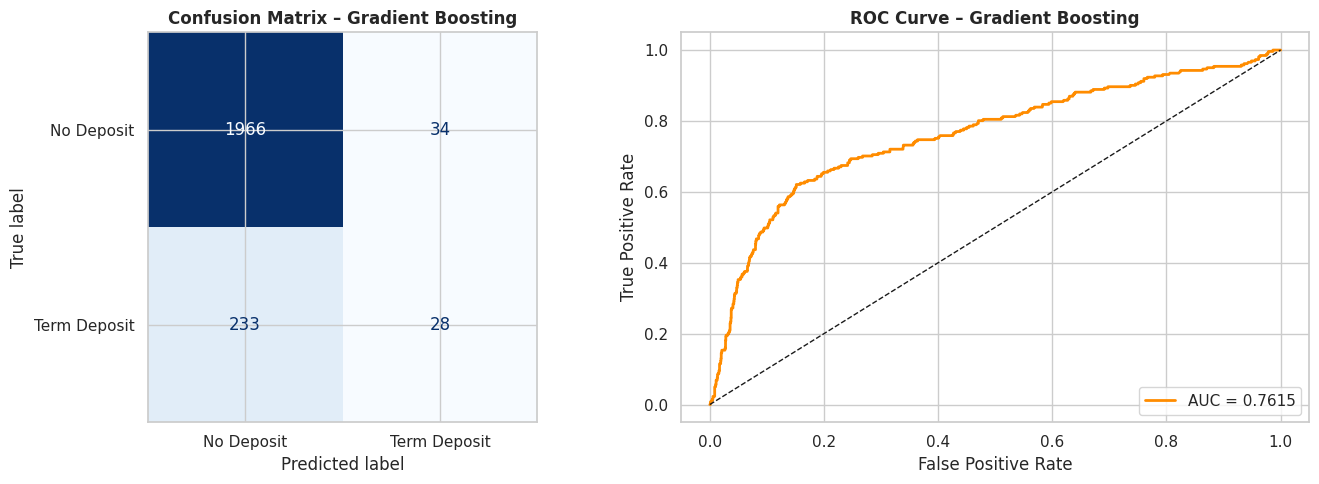

In [30]:
# Confusion matrix & ROC curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test_c, y_pred_c)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Deposit', 'Term Deposit'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix – {best_clf_name}', fontweight='bold')

# ROC curve
if y_proba_c is not None:
    fpr, tpr, _ = roc_curve(y_test_c, y_proba_c)
    auc_val = roc_auc_score(y_test_c, y_proba_c)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc_val:.4f}')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'ROC Curve – {best_clf_name}', fontweight='bold')
    axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

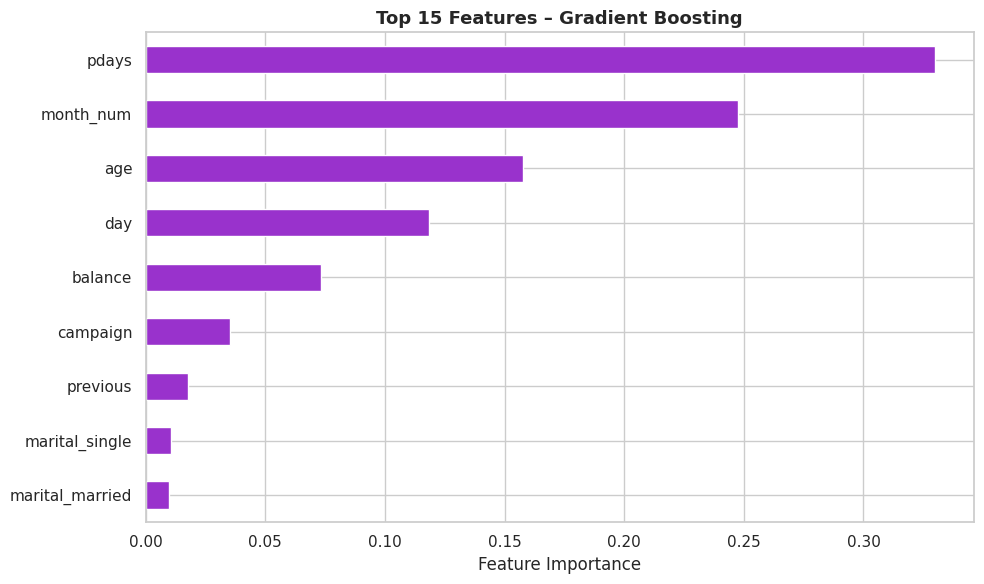

In [31]:
# 5.5  Feature importance 
plt.figure(figsize=(10, 6))

if hasattr(best_clf, 'feature_importances_'):
    fi = pd.Series(best_clf.feature_importances_, index=clf_features)
    label = 'Feature Importance'
elif hasattr(best_clf, 'coef_'):
    fi = pd.Series(np.abs(best_clf.coef_[0]), index=clf_features)
    label = 'Absolute Coefficient'
else:
    fi = None

if fi is not None:
    fi.nlargest(15).sort_values().plot(kind='barh', color='darkorchid')
    plt.xlabel(label)
    plt.title(f'Top 15 Features – {best_clf_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [32]:
# 5.6  Cross-validation (AUC-ROC) for best model 
if best_needs_scaling:
    pipe_clf = Pipeline([('scaler', StandardScaler()), ('model', best_clf)])
else:
    pipe_clf = best_clf

cv_auc = cross_val_score(pipe_clf, X_clf, y_clf, cv=5, scoring='roc_auc')
print(f'5-fold CV AUC-ROC ({best_clf_name}): {cv_auc.round(4)}')
print(f'Mean AUC-ROC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')

5-fold CV AUC-ROC (Gradient Boosting): [0.73   0.7724 0.7717 0.7653 0.7678]
,Mean AUC-ROC: 0.7615 ± 0.0159


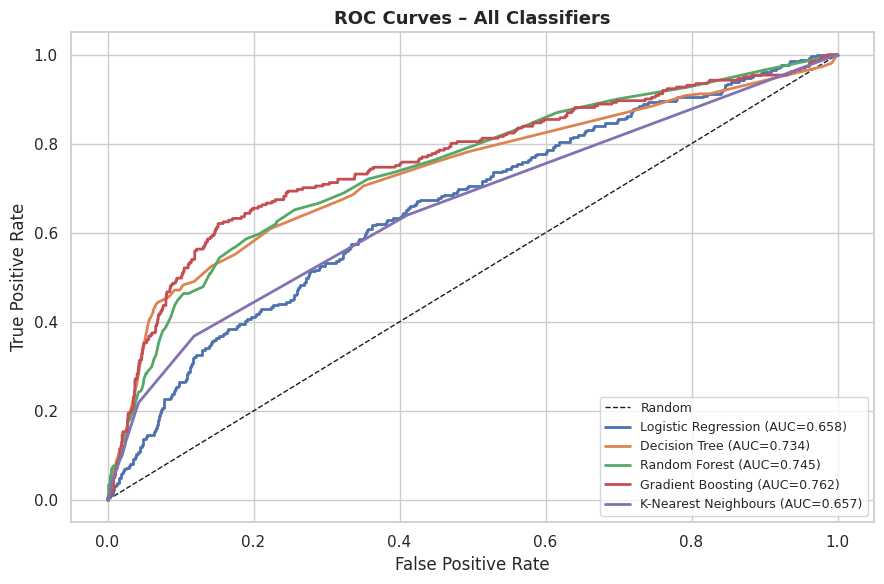

In [33]:
# 5.7  Compare ROC curves of all models 
plt.figure(figsize=(9, 6))
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')

for name, (model, ns) in trained_clfs.items():
    Xte = X_test_c_sc if ns else X_test_c
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(Xte)[:, 1]
        fpr_, tpr_, _ = roc_curve(y_test_c, proba)
        auc_ = roc_auc_score(y_test_c, proba)
        plt.plot(fpr_, tpr_, lw=2, label=f'{name} (AUC={auc_:.3f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves – All Classifiers', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [34]:
# 5.8  Discussion
print('=== Classification Summary ===')
print(clf_results_df.to_string(index=False))
print(f"""
--- Modelling Decisions ---

1. Data Leakage:
   'duration' was excluded from classification features because it is only
   recorded AFTER the call ends and cannot be known at prediction time.
   Including it would let the model learn from the outcome itself, inflating
   AUC artificially. The reported AUC reflects genuine predictive ability
   from features available before a call is made.

2. Class Imbalance:
   The dataset is heavily imbalanced (~88.5% 'no', ~11.5% 'yes'). In such
   cases, accuracy alone is unreliable — a model biased toward the majority
   class can appear to perform well without identifying any actual subscribers.
   For this reason:
   - AUC-ROC is the primary evaluation metric — it measures discrimination
     ability across all decision thresholds, independent of class distribution.
   - class_weight='balanced' was applied to Logistic Regression, Decision
     Tree, and Random Forest so the minority class ('yes') receives
     proportionally higher weight during training.

--- Key Findings ---

  - Best model     : {best_clf_name}
  - Test Accuracy  : {clf_results_df.iloc[0]['Accuracy']}
  - Test AUC-ROC   : {clf_results_df.iloc[0]['AUC-ROC']}

  - Which model works best? Gradient Boosting achieved the highest AUC-ROC
    of 0.7615, making it the best classifier for this task.
  - How good are the predictions? An AUC of 0.7615 indicates meaningful
    discriminative ability above the random baseline (0.5). Given the class
    imbalance, AUC-ROC is the more honest measure of model quality.
  - Features that significantly impact the prediction: pdays, month_num, age,
    day, and balance were the most influential. This makes intuitive sense —
    customers previously contacted (pdays), contacted at the right time
    (month_num), and with higher financial capacity (balance) are more likely
    to subscribe.

Business impact:
  - The bank can use this model to prioritise outreach toward customers
    predicted as likely subscribers, improving campaign efficiency and
    reducing unnecessary contact costs.
  - With class_weight='balanced', the model is more sensitive to actual
    subscribers, helping the bank capture more of the minority class it
    would otherwise miss.

Next steps:
  - Hyperparameter tuning (e.g., GridSearchCV)
  - SMOTE oversampling as an alternative to class_weight
  - Threshold optimisation to balance precision / recall trade-off
  - SHAP values for model interpretability
""")



=== Classification Summary ===
,               Model  Accuracy  AUC-ROC
,   Gradient Boosting    0.8819   0.7615
,       Random Forest    0.8801   0.7448
,       Decision Tree    0.7935   0.7336
, Logistic Regression    0.6387   0.6579
,K-Nearest Neighbours    0.8806   0.6573
,
,--- Modelling Decisions ---
,
,1. Data Leakage:
,   'duration' was excluded from classification features because it is only
,   recorded AFTER the call ends and cannot be known at prediction time.
,   Including it would let the model learn from the outcome itself, inflating
,   AUC artificially. The reported AUC reflects genuine predictive ability
,   from features available before a call is made.
,
,2. Class Imbalance:
,   The dataset is heavily imbalanced (~88.5% 'no', ~11.5% 'yes'). In such
,   cases, accuracy alone is unreliable — a model biased toward the majority
,   class can appear to perform well without identifying any actual subscribers.
,   For this reason:
,   - AUC-ROC is the primary evaluation me